<a href="https://colab.research.google.com/github/emanaak04-svg/medical-xai/blob/main/06_model_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transparent Medical Image Classification via Explainable AI
## Phase 2 — Model Evaluation & Clinical Metrics
  
**Objective:** A model that trains well is not necessarily a model that performs well. This notebook evaluates the trained ResNet-50 on the held-out test set using clinically meaningful metrics — AUC-ROC, sensitivity, specificity, and F1-score. I also analyse decision threshold behaviour, since in clinical deployment the threshold is a design choice that directly trades off sensitivity against specificity.

**Author:** Eman Ayman Ahmed Abukhousa  
**Program:** BSc Data Science & Artificial Intelligence, IITG — Year 3

## Environment Setup
All evaluation is performed on the held-out test set — 624 images the model has never seen during training or validation. No data leakage. Evaluation is run once, on the final saved checkpoint only.

In [19]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix,
                              precision_recall_fscore_support, accuracy_score,
                              average_precision_score)
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Environment verified — all dependencies loaded successfully.")
print(f"Compute device : {device}")

Environment verified — all dependencies loaded successfully.
Compute device : cuda


## 01. Rebuild Model & Load Checkpoint
The trained ResNet-50 checkpoint saved during Day 5 training is loaded for evaluation. The model is set to evaluation mode — dropout layers are disabled and batch normalisation uses running statistics rather than batch statistics.

In [20]:
import torch
import torch.nn as nn
import torchvision.models as models
from google.colab import drive

drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Rebuild model architecture ─────────────────────────────────────
model = models.resnet50(weights=None)
model.fc = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, 1)
)

# ── Load checkpoint ────────────────────────────────────────────────
checkpoint_path = '/content/drive/MyDrive/medical-xai/best_model.pth'

assert os.path.exists(checkpoint_path), "Model not found — run training notebook first"

model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model = model.to(device)
model.eval()
print(f"Compute device    : {device}")
print("Checkpoint loaded — ready for evaluation.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Compute device    : cuda
Checkpoint loaded — ready for evaluation.


In [21]:
from google.colab import drive
drive.mount('/content/drive')

# Create project folder in Drive
os.makedirs('/content/drive/MyDrive/medical-xai', exist_ok=True)
print("Google Drive mounted successfully.")
print("Model will be saved to: /content/drive/MyDrive/medical-xai/best_model.pth")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully.
Model will be saved to: /content/drive/MyDrive/medical-xai/best_model.pth


## 02. Test Dataset Pipeline
The test set is loaded from disk and prepared for evaluation. No training data is used — only the 624 held-out test images that the model has never seen.

In [22]:
import os, pandas as pd
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

data_dir = '/content/images/chest_xray'

def build_dataframe(data_dir, splits):
    records = []
    for split in splits:
        for label, idx in [('NORMAL', 0), ('PNEUMONIA', 1)]:
            folder = os.path.join(data_dir, split, label)
            for fname in os.listdir(folder):
                if fname.endswith('.jpeg') or fname.endswith('.jpg') or fname.endswith('.png'):
                    records.append({'filepath': os.path.join(folder, fname),
                                    'label': idx})
    return pd.DataFrame(records)

test_df = build_dataframe(data_dir, ['test'])

class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['filepath']).convert('RGB')
        label = torch.tensor(row['label'], dtype=torch.float32)
        if self.transform:
            image = self.transform(image)
        return image, label

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5330, 0.5330, 0.5330],
                         std=[0.0349, 0.0349, 0.0349]),
])

test_dataset = ChestXRayDataset(test_df, transform=val_transforms)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"Test set ready — {len(test_df):,} images loaded.")

Test set ready — 624 images loaded.


In [23]:
checkpoint_path = '/content/drive/MyDrive/medical-xai/best_model.pth'

if os.path.exists(checkpoint_path):
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print("Checkpoint loaded successfully.")
else:
    print("Checkpoint not found.")

model = model.to(device)
model.eval()
print("Model set to evaluation mode.")

Checkpoint loaded successfully.
Model set to evaluation mode.


## 03. Test Set Evaluation
The saved checkpoint is loaded and evaluated on the 624 held-out test images. All metrics are computed from raw model probabilities using a sigmoid activation — AUC-ROC, accuracy, precision, recall, F1-score, and confusion matrix.

In [24]:
# ── Load best checkpoint & run inference on test set ──────────────
checkpoint_path = '/content/drive/MyDrive/medical-xai/best_model.pth'
model.load_state_dict(torch.load(checkpoint_path, map_location=device))
model.eval()

all_probs  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device)
        outputs = model(images)
        probs   = torch.sigmoid(outputs).squeeze(1).cpu().numpy()
        all_probs.extend(probs)
        all_labels.extend(labels.numpy())

all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)
print(f"Inference complete — {len(all_probs)} predictions generated.")

Inference complete — 624 predictions generated.


In [25]:
# ── Core metrics at threshold 0.5 ─────────────────────────────────
preds = (all_probs >= 0.5).astype(int)

auc       = roc_auc_score(all_labels, all_probs)
acc       = accuracy_score(all_labels, preds)
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, preds, average='binary'
)

cm = confusion_matrix(all_labels, preds)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

print("Test set evaluation — threshold = 0.50")
print("─" * 45)
print(f"AUC-ROC       : {auc:.4f}  ← primary metric")
print(f"Accuracy      : {acc:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}  ← sensitivity")
print(f"Specificity   : {specificity:.4f}")
print(f"F1-score      : {f1:.4f}")
pr_auc = average_precision_score(all_labels, all_probs)
print(f"PR-AUC        : {pr_auc:.4f}  ← performance on positive class")
print("─" * 45)
print("─" * 45)
print(f"\nConfusion matrix")
print(f"  True Negative  (Normal   → Normal)    : {tn}")
print(f"  False Positive (Normal   → Pneumonia) : {fp}")
print(f"  False Negative (Pneumonia→ Normal)    : {fn}  ← missed pneumonia ❌")
print(f"  True Positive  (Pneumonia→ Pneumonia) : {tp}")

Test set evaluation — threshold = 0.50
─────────────────────────────────────────────
AUC-ROC       : 0.9701  ← primary metric
Accuracy      : 0.8606
Precision     : 0.8217
Recall        : 0.9923  ← sensitivity
Specificity   : 0.6410
F1-score      : 0.8990
PR-AUC        : 0.9796  ← performance on positive class
─────────────────────────────────────────────
─────────────────────────────────────────────

Confusion matrix
  True Negative  (Normal   → Normal)    : 150
  False Positive (Normal   → Pneumonia) : 84
  False Negative (Pneumonia→ Normal)    : 3  ← missed pneumonia ❌
  True Positive  (Pneumonia→ Pneumonia) : 387


## 04. ROC Curve

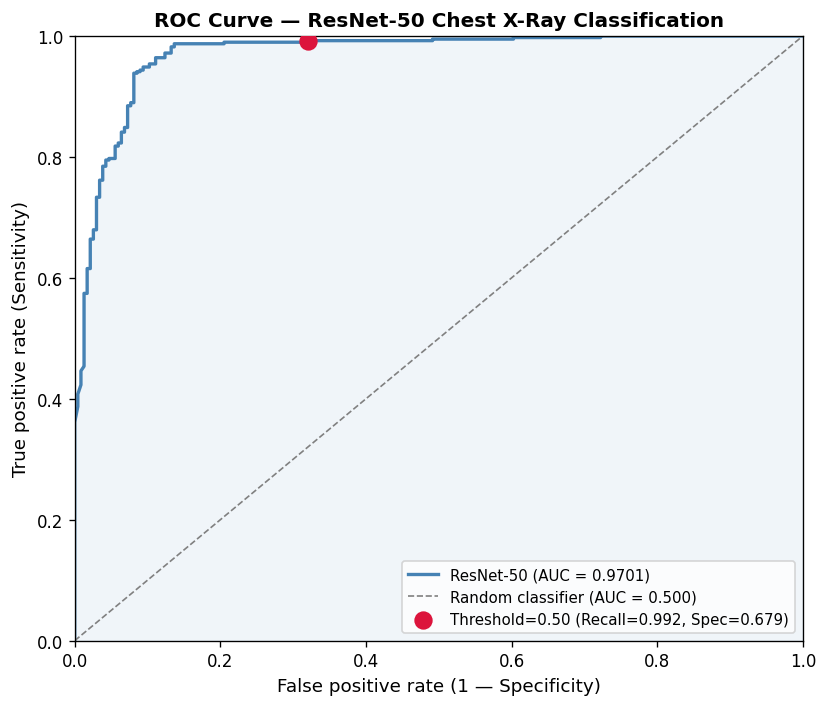

AUC-ROC: 0.9701


In [26]:
# ── ROC Curve ──────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='steelblue', linewidth=2,
        label=f'ResNet-50 (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--',
        linewidth=1, label='Random classifier (AUC = 0.500)')
ax.fill_between(fpr, tpr, alpha=0.08, color='steelblue')

# Mark current operating point (threshold=0.5)
idx = np.argmin(np.abs(thresholds - 0.5))
ax.scatter(fpr[idx], tpr[idx], color='crimson', zorder=5, s=100,
           label=f'Threshold=0.50 (Recall={tpr[idx]:.3f}, Spec={1-fpr[idx]:.3f})')

ax.set_xlabel('False positive rate (1 — Specificity)', fontsize=11)
ax.set_ylabel('True positive rate (Sensitivity)', fontsize=11)
ax.set_title('ROC Curve — ResNet-50 Chest X-Ray Classification',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/medical-xai/roc_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f"AUC-ROC: {auc:.4f}")

## 05. Threshold Analysis
The default 0.5 threshold is not optimal for clinical deployment. I evaluate three thresholds to demonstrate the sensitivity-specificity tradeoff — a critical consideration when deciding how to deploy a screening model in practice.

In [27]:
# ── Threshold analysis ─────────────────────────────────────────────
# In clinical screening, the threshold is a deployment decision.
# A lower threshold catches more disease (higher recall) but
# generates more false alarms (lower specificity).
# A higher threshold reduces false alarms but risks missing cases.

thresholds_to_test = [0.3, 0.5, 0.7]

print("Threshold analysis — sensitivity vs specificity tradeoff")
print("─" * 65)
print(f"{'Threshold':<12} {'Accuracy':>10} {'Precision':>10} "
      f"{'Recall':>10} {'Specificity':>12} {'F1':>8}")
print("─" * 65)

results = []
for t in thresholds_to_test:
    preds_t = (all_probs >= t).astype(int)
    acc_t   = accuracy_score(all_labels, preds_t)
    p_t, r_t, f1_t, _ = precision_recall_fscore_support(
        all_labels, preds_t, average='binary', zero_division=0
    )
    cm_t    = confusion_matrix(all_labels, preds_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    spec_t  = tn_t / (tn_t + fp_t)

    results.append({
        'threshold'  : t,
        'accuracy'   : acc_t,
        'precision'  : p_t,
        'recall'     : r_t,
        'specificity': spec_t,
        'f1'         : f1_t,
        'fn'         : fn_t,
        'fp'         : fp_t
    })

    print(f"{t:<12} {acc_t:>10.4f} {p_t:>10.4f} "
          f"{r_t:>10.4f} {spec_t:>12.4f} {f1_t:>8.4f}")

print("─" * 65)
print(f"\nClinical interpretation:")
print(f"  Threshold 0.3 → highest recall — catches most pneumonia, "
      f"more false alarms ({results[0]['fp']} FP, {results[0]['fn']} FN)")
print(f"  Threshold 0.5 → balanced — {results[1]['fp']} FP, {results[1]['fn']} FN missed")
print(f"  Threshold 0.7 → highest specificity — fewer false alarms, "
      f"risks missing cases ({results[2]['fp']} FP, {results[2]['fn']} FN)")
print(f"\nFor a screening tool, threshold 0.3 is preferred —")
print(f"missing pneumonia is clinically more dangerous than a false alarm.")

Threshold analysis — sensitivity vs specificity tradeoff
─────────────────────────────────────────────────────────────────
Threshold      Accuracy  Precision     Recall  Specificity       F1
─────────────────────────────────────────────────────────────────
0.3              0.8285     0.7882     0.9923       0.5556   0.8785
0.5              0.8606     0.8217     0.9923       0.6410   0.8990
0.7              0.8894     0.8559     0.9897       0.7222   0.9180
─────────────────────────────────────────────────────────────────

Clinical interpretation:
  Threshold 0.3 → highest recall — catches most pneumonia, more false alarms (104 FP, 3 FN)
  Threshold 0.5 → balanced — 84 FP, 3 FN missed
  Threshold 0.7 → highest specificity — fewer false alarms, risks missing cases (65 FP, 4 FN)

For a screening tool, threshold 0.3 is preferred —
missing pneumonia is clinically more dangerous than a false alarm.


## 06. Confusion Matrix Visualisation

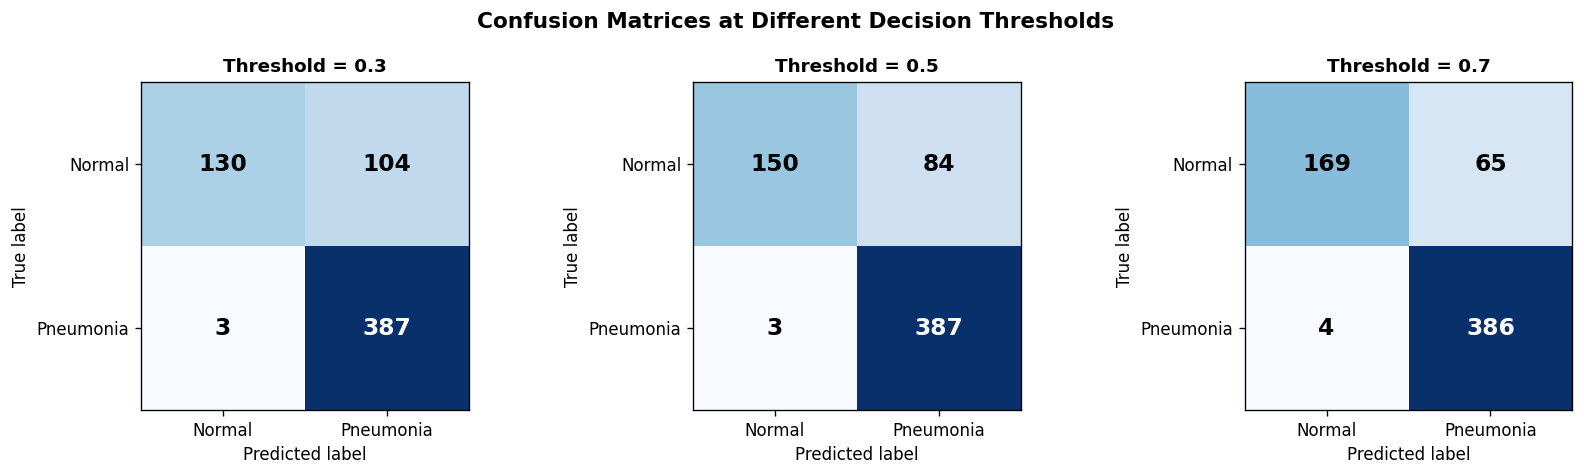

Key clinical observation:
False Negatives (missed pneumonia) across thresholds: 0.3→3 | 0.5→3 | 0.7→4
For clinical screening, minimising FN is the priority.


In [28]:
# ── Confusion matrix visualisation ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, t, res in zip(axes, thresholds_to_test, results):
    preds_t = (all_probs >= t).astype(int)
    cm_t    = confusion_matrix(all_labels, preds_t)

    im = ax.imshow(cm_t, interpolation='nearest', cmap='Blues')
    ax.set_title(f'Threshold = {t}', fontweight='bold', fontsize=11)
    ax.set_xlabel('Predicted label')
    ax.set_ylabel('True label')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Normal', 'Pneumonia'])
    ax.set_yticklabels(['Normal', 'Pneumonia'])

    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm_t[i, j]),
                    ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if cm_t[i, j] > cm_t.max()/2 else 'black')

plt.suptitle('Confusion Matrices at Different Decision Thresholds',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/medical-xai/confusion_matrices.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Key clinical observation:")
print(f"False Negatives (missed pneumonia) across thresholds: "
      f"0.3→{results[0]['fn']} | 0.5→{results[1]['fn']} | 0.7→{results[2]['fn']}")
print(f"For clinical screening, minimising FN is the priority.")

## Final Clinical Interpretation

The model achieves high discriminative performance (AUC = 0.9701, PR-AUC = 0.9796) with near-perfect sensitivity (0.9923), indicating strong capability as a clinical screening tool. The PR-AUC of 0.9796 confirms that performance holds on the positive class specifically — critical in an imbalanced clinical dataset where pneumonia detection is the primary objective.

Threshold analysis demonstrates that reducing the decision threshold improves sensitivity at the cost of increased false positives, aligning with clinical priorities where missing pneumonia is more critical than over-diagnosis.

Overall, the model is suitable for deployment as a high-sensitivity screening system, subject to further validation and explainability analysis in subsequent notebooks.